# Real World Data Wrangling

# 1. Gather data

# Age, Gender, and the Risk Within: 
## Insights into Cardiovascular and Stroke Occurrence
The aim of this analysis is to examine the rate of cardiovascular disease and stroke occurrence by **gender and age group**.  
Using patient data from cardiovascular and stroke datasets, the goal is to identify patterns and trends that may highlight differences in disease occurrence across demographics.


In [5]:
import numpy as np
import pandas as pd
import requests
import matplotlib as mpl
import zipfile
import os
import seaborn as sns
import matplotlib.pyplot as plt
import os 
from kaggle.api.kaggle_api_extended import KaggleApi

# Dataset 1

**Type:** CSV File 

**Method:** The dataset was programmatically retrieved using the Kaggle API. The Python script authenticated with Kaggle, downloaded the dataset directly into the workspace, and loaded it into a pandas DataFrame for analysis.

**Dataset variables:**

- **Variable 1:** `id` – Unique identifier for each patient/record
- **Variable 2:** `age` – Age in days
- **Variable 3:** `gender` – Gender
- **Variable 4:** `height` – Height in centimeters  
- **Variable 5:** `weight` – Weight in kilograms  
- **Variable 6:** `ap_hi` – Systolic blood pressure  
- **Variable 7:** `ap_lo` – Diastolic blood pressure  
- **Variable 8:** `cholesterol` – Cholesterol level 
- **Variable 9:** `gluc` – Glucose level    
- **Variable 10:** `smoke` – Smoking status  
- **Variable 11:** `alco` – Alcohol intake 
- **Variable 12:** `active` – Physical activity  
- **Variable 13:** `cardio` – Presence of cardiovascular disease

In [6]:
# Paths
sample_csv = 'data_store/heart_data_1000.csv'
full_csv = 'data_store/heart_data.csv'

# Check if reduced sample already exists
if not os.path.exists(sample_csv):
    print('Sample not found. Downloading dataset from Kaggle...')

    # Authenticate Kaggle API
    api = KaggleApi()
    api.authenticate()

    # Download and unzip full dataset
    api.dataset_download_files(
        'thedevastator/exploring-risk-factors-for-cardiovascular-diseas',
        path='data_store/',
        unzip=True
    )

    # Load first 1000 rows only
    cardio_health = pd.read_csv(full_csv, nrows=1000)

    # Save reduced dataset
    cardio_health.to_csv(sample_csv, index=False)
    print(f" Saved reduced dataset ({len(cardio_health)} rows) at: {sample_csv}")

    # Delete full dataset to save space
    if os.path.exists(full_csv):
        os.remove(full_csv)
        print(f" Deleted full dataset: {full_csv}")
else:
    print('Using existing reduced dataset.')
    cardio_health = pd.read_csv(sample_csv)

print(f"Loaded cardio dataset with {len(cardio_health)} rows")

Sample not found. Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/thedevastator/exploring-risk-factors-for-cardiovascular-diseas
 Saved reduced dataset (1000 rows) at: data_store/heart_data_1000.csv
 Deleted full dataset: data_store/heart_data.csv
Loaded cardio dataset with 1000 rows


In [7]:
# Display the dataset preview
cardio_health

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1381,19640,2,167,64.0,110,70,1,1,0,0,0,0
996,996,1383,18951,1,168,78.0,120,80,1,1,0,0,1,1
997,997,1385,18751,1,149,56.0,140,80,1,1,0,0,1,1
998,998,1386,17371,1,156,74.0,150,90,1,1,0,0,0,1


# Dataset 2

**Type:** CSV File

**Method:** The data was gathered manually from the my local Downloads folder and loaded into Python using pandas.

**Dataset variables:**

- **Variable 1:** `gender` – Gender of the patient  
- **Variable 2:** `age` – Age of the patient in years  
- **Variable 3:** `hypertension` – Whether the patient has hypertension   
- **Variable 4:** `heart_disease` – Whether the patient has heart disease   
- **Variable 5:** `ever_married` – Marital status of the patient   
- **Variable 6:** `work_type` – Type of work 
- **Variable 7:** `Residence_type` – Residence type  
- **Variable 8:** `avg_glucose_level` – Average glucose level in blood  
- **Variable 9:** `bmi` – Body Mass Index of the patient  
- **Variable 10:** `smoking_status` – Smoking status  
- **Variable 11:** `stroke` – Stroke occurrence 

In [8]:
# Define the path to the brain stroke dataset (CSV file in Downloads folder)
csv_file = os.path.expanduser('~/Downloads/brain_stroke.csv')

# Check if the file exists before attempting to load
if os.path.isfile(csv_file):
    print(f"Found file at: {csv_file}")
    
    # Load the CSV into a pandas DataFrame
    brain_stroke = pd.read_csv(csv_file)
    print("Data successfully loaded")
else:
    # If the file is not found, raise an error
    raise FileNotFoundError(f" {csv_file} does not exist!")

Found file at: /Users/kristablevins/Downloads/brain_stroke.csv
Data successfully loaded


In [9]:
# Ensure the 'data_store' folder exists (create if missing)
os.makedirs('data_store', exist_ok=True)

In [10]:
# Define the path where the dataset will be stored in the project folder
save_path = os.path.join('data_store', 'brain_stroke.csv')

In [11]:
# Save a clean copy of the dataset into the 'data_store' directory
brain_stroke.to_csv(save_path, index=False)
print(f"Data saved successfully at: {save_path}")

Data saved successfully at: data_store/brain_stroke.csv


In [12]:
# Reload the stroke dataset from the data_store folder for use in analysis
stroke_df = pd.read_csv('data_store/brain_stroke.csv')
stroke_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


# Section 2 & 3: Data Assessment and Cleaning

In [13]:
# Path to raw data folder
data_store = "data_store"
# Verfied folder contents
os.listdir(data_store) 

['heart_data_1000.csv', 'brain_stroke.csv']

In [14]:
# Load cardio dataset into data frame
cardio = pd.read_csv(os.path.join(data_store, "heart_data_1000.csv"))

# Load brain stroke dataset into data frame
stroke = pd.read_csv(os.path.join(data_store, "brain_stroke.csv"))

# Size check
print(cardio.shape)
print(stroke.shape)

(1000, 14)
(4981, 11)


In [16]:
# Create a dedicated folder for raw sample datasets
sample_folder = 'data_store/raw'
# If the folder does not exist, create it; if it exists, do nothing
os.makedirs(sample_folder, exist_ok=True)

# Reduce datasets and create random samlpe
cardio_raw = cardio.sample(n=1000, random_state=42)
stroke_raw = stroke.sample(n=1000, random_state=42)

# Verify before and after 
print('Original cardio dataset size:', len(cardio))
print('Reduced cardio dataset size:', len(cardio_raw))
print('\nOriginal stroke dataset size:', len(stroke))
print('Reduced stroke dataset size:', len(stroke_raw))

# Save the samples in the dedicated folder (overwrite each run)
cardio_raw.to_csv(f'{sample_folder}/cardio_raw.csv', index=False)
stroke_raw.to_csv(f'{sample_folder}/stroke_raw.csv', index=False)

# Confirm data was saved to folder
print(f"\nSample datasets saved in '{sample_folder}' and will be updated on each run.")

Original cardio dataset size: 1000
Reduced cardio dataset size: 1000

Original stroke dataset size: 4981
Reduced stroke dataset size: 1000

Sample datasets saved in 'data_store/raw' and will be updated on each run.


# Why Study Cardiovascular Risk Factors?

**Relevance:** Cardiovascular disease (CVD) is one of the leading cause of death globally. Understanding its risk factors—such as age, blood pressure, cholesterol, BMI, and lifestyle habits—helps identify individuals at higher risk and informs prevention strategies.

**Data Availability:** Datasets on cardiovascular health typically include both demographic and clinical variables, allowing for comprehensive analysis of how these factors interact and contribute to health.

**Analysis Opportunities:**
- **Predictive modeling:** Assess which risk factors most strongly influence heart disease or stroke.
- **Preventive insights:** Highlight modifiable behaviors (smoking, physical activity, diet) that may reduce risk.
- **Data cleaning and preprocessing practice:** Real-world health datasets often include missing values, outliers, or non-standard coding, making them ideal for developing robust data cleaning workflows.

**Practical Impact:** Analyzing cardiovascular risk factors supports evidence-based interventions, improves patient outcomes, and provides actionable insights for public health policy.

## Data Audit:
## Quickly Identify Data Quality Issues
Why I am using `data_audit`, it provides a quick snapshot of the dataset structure, data types, missing values, basic statistics, and sample rows. 

In [17]:
# Perform data audit
def data_audit(df, top_n=5):
   # Quick overview of dataset
    print('Shape of DataFrame:', df.shape) # size
    print('\nColumns:', df.columns.tolist()) # shape
    print('\nData Types:\n', df.dtypes) # datatype
    print('\nMissing Values per Column:\n', df.isnull().sum()) # missing values
    
    # Numeric column summary
    print('\nNumeric Summary:')
    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe()) # summary statisitcs 
    else:
        print("No numeric columns")
        
    # Categorical column summary
    print('\nCategorical Summary:')
    categorical_cols = df.select_dtypes(include='object').columns
    if len(categorical_cols) > 0:
        for col in categorical_cols:
            print(f"\nColumn: {col}")
            print(f"Unique values: {df[col].nunique()}") # count value type
            print(f"Column values count for: {df[col].value_counts().head(top_n)}")
    else:
        print('No categorical columns')
        
    # Display first few rows
    print('\nFirst 5 Rows:\n', df.head())

# Cardiovascular Risk Dataset: Assessment

In [18]:
# Call function on dataset
data_audit(cardio_raw)

Shape of DataFrame: (1000, 14)

Columns: ['index', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

Data Types:
 index            int64
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing Values per Column:
 index          0
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Numeric Summary:
             index           id          age       gender       height  \
count  1000.000000  1000.000000   1000.00000  1000.000000  1000.000000   
mean    499.500000   701.971000 

# Promote tidiness and clarity by dropping non-essential columns

In [19]:
# Create a clean copy while dropping unnecessary columns
cardio_clean = cardio_raw.drop(columns=['height', 'weight', 'gluc','alco', 'active'])

In [20]:
# Correction 1
print('\nCardio Age Column Preview:\n', cardio_clean['age'].head().to_list())


Cardio Age Column Preview:
 [15991, 16808, 18996, 18117, 20295]


In [21]:
# Corrections 2
print('\nPotential Outliers:\n', cardio_clean[['ap_hi', 'ap_lo']].describe())


Potential Outliers:
              ap_hi        ap_lo
count  1000.000000  1000.000000
mean    127.463000    92.655000
std      18.106918   102.072635
min      11.000000    30.000000
25%     120.000000    80.000000
50%     120.000000    80.000000
75%     140.000000    90.000000
max     200.000000  1100.000000


**Issues:** Patient ages in the dataset are recorded in days rather than years, which is unusual for medical datasets and makes interpretation, analysis, and comparison with other studies difficult. Additionally, some values in the `ap_hi` and `ap_lo` column appear extremely low or high, indicating potential outliers such as negative values or implausibly values.

# Data Quality Issue: Age Conversion

**Dataset:** Cardio Sample Dataset

**Issue:** The age column is recorded in days, which is unusual for medical data and makes interpretation, reporting, and analysis difficult. 

**Check Performed:** Verified that all age values were correctly converted to years and fall within plausible human age ranges.

**Results:** Converted age from days to years and stored the result as integer value in the same column for clarity and consistency.

**Justification:** Converting to years ensures the data is interpretable and comparable, aligns with standard medical reporting, and enables meaningful age-based analysis, grouping, and visualization.

In [22]:
# Convert age from days to years and replace original 'age' column in-place
cardio_clean['age'] = (cardio_clean['age'] / 365.25).astype(int)

# Preview the cleaned age column
print(cardio_clean[['age']].head())

     age
521   43
737   46
740   52
660   49
411   55


# Tidiness Issue: Gender Coding

**Dataset:** Cardio Sample Dataset

**Before:** The gender column uses numeric codes (1 and 2). While this is technically “one column per variable,” the values themselves are not interpretable. 

**After:** Each numeric code is replaced with a descriptive label (Female, Male).

**This improves tidiness because:** 
- **Self-describing columns:** The gender column now directly tells the patient’s gender.

**No external reference needed:** Every row fully describes the patient’s data. 

**Ready for analysis:** You can group, filter, or visualize by gender without additional mapping.

**Solution:** Recode the numeric codes to descriptive labels
- 1 → Female
- 2 → Male

In [23]:
# Recode numeric gender codes to descriptive labels and convert to object type
gender_map = {1: 'Female', 2: 'Male'}
cardio_clean['gender'] = cardio_clean['gender'].map(gender_map).astype(object)

# Verify data object type change
print(cardio_clean['gender'].value_counts())

gender
Female    641
Male      359
Name: count, dtype: int64


# Tidiness Issue: Cholesterol

**Dataset:** Cardio Sample Dataset


**Before:** Numeric codes (1, 2, 3) are used. While this is technically “one column per variable,” the values themselves are not interpretable. Analysts or models need a separate reference to understand what each number means.

**After:** Each numeric code is replaced with a descriptive label (Desirable, Borderline High, High).

**This improves tidiness because:**
- Self-describing columns: The cholesterol column now directly tells the category of cholesterol.
- No external reference needed: Every row fully describes the patient’s data.
- Ready for analysis: You can group, filter, or visualize by cholesterol category without additional mapping.
So tidiness isn’t just about structure—it’s also about making the values meaningful and interpretable within the dataset.

**Solution** Recode the numeric codes to **descriptive labels** This makes the dataset **tidy and readable**, with each cell containing a meaningful value.
  - `1` → Desirable (<200 mg/dL)  
  - `2` → Borderline High (200–239 mg/dL)  
  - `3` → High (≥240 mg/dL)  

In [24]:
# Map numeric cholesterol codes to descriptive labels for clarity
cholesterol_map = {1: 'Desirable', 2: 'Borderline High', 3: 'High'}
cardio_clean['cholesterol'] = cardio_clean['cholesterol'].map(cholesterol_map).astype(object)

# Verify data
print(cardio_clean.dtypes)

index           int64
id              int64
age             int64
gender         object
ap_hi           int64
ap_lo           int64
cholesterol    object
smoke           int64
cardio          int64
dtype: object


# Dropping Invalid Blood Pressure Rows

**Dataset:** Cardio Sample Dataset

**Issue:** Some rows contain physiologically implausible blood pressure values (negative readings, extremely high or low measurements), which could distort analysis.

**Check Performed:** The `check_all_bp` function was applied to identify invalid systolic (ap_hi) and diastolic (ap_lo) values. Counts of invalid rows were examined before cleaning.

**Results:** All rows flagged as invalid were removed from cardio_clean, producing a cleaned dataset cardio_clean_drop.

**Justification:** Ensures that all remaining blood pressure values are medically plausible, preventing extreme values from skewing statistical summaries and enabling reliable analysis.

In [27]:
def check_all_bp(cardio_clean, Systolic='ap_hi', Diastolic='ap_lo'):
    #Identify all out-of-range blood pressure values in the dataset.
    invalid = {
        "Negative_Systolic": cardio_clean[cardio_clean[Systolic] <= 0], 
        "Low_Systolic": cardio_clean[(cardio_clean[Systolic] < 90) & (cardio_clean[Systolic] > 0)],  
        "High_Systolic": cardio_clean[cardio_clean[Systolic] > 220],  
        "Negative_Diastolic": cardio_clean[cardio_clean[Diastolic] <= 0], 
        "Low_Diastolic": cardio_clean[(cardio_clean[Diastolic] < 60) & (cardio_clean[Diastolic] > 0)],  
        "High_Diastolic": cardio_clean[cardio_clean[Diastolic] > 120]  
    }
    return invalid
invalid_bp = check_all_bp(cardio_clean)  # cardio_clean must be your BP dataset

In [28]:
# Combine all invalid rows into a single DataFrame with a BP_issue list
all_invalid_rows = pd.concat(invalid_bp.values()).drop_duplicates()

# Create a new column to store all applicable BP categories for each row
def list_bp_issues(row, Systolic='ap_hi', Diastolic='ap_lo'):
    issues = []
    # Systolic conditions
    if row[Systolic] <= 0:
        issues.append("Negative_Systolic")
    elif row[Systolic] < 90:
        issues.append("Low_Systolic")
    elif row[Systolic] > 220:
        issues.append("High_Systolic")
    # Diastolic conditions
    if row[Diastolic] <= 0:
        issues.append("Negative_Diastolic")
    elif row[Diastolic] < 60:
        issues.append("Low_Diastolic")
    elif row[Diastolic] > 120:
        issues.append("High_Diastolic")
    return issues

all_invalid_rows['BP_issues_list'] = all_invalid_rows.apply(list_bp_issues, axis=1)

# Optional: create a column showing multiple issues as a string
all_invalid_rows['BP_issues_str'] = all_invalid_rows['BP_issues_list'].apply(lambda x: ', '.join(x))

# Preview
print(all_invalid_rows[['ap_hi', 'ap_lo', 'BP_issues_str']].head())

     ap_hi  ap_lo                BP_issues_str
636     70    110                 Low_Systolic
209     80     70                 Low_Systolic
567     14     90                 Low_Systolic
383     80     50  Low_Systolic, Low_Diastolic
927     14     90                 Low_Systolic


In [29]:
# Drop invalid rows to create a cleaned dataset
cardio_clean_drop = cardio_clean.drop(all_invalid_rows.index)
# # Verify data drop
cardio_clean_drop.shape

(978, 9)

# Visualizing Out-of-Range Blood Pressure Values

**Description:** A scatter plot was created for all out-of-range systolic (ap_hi) and diastolic (ap_lo) values in the cardio_sample dataset.

**Insights:** The visualization highlights clusters of abnormal blood pressure readings as well as extreme values that fall outside physiologically plausible ranges. This helps identify potential data entry errors or measurement anomalies and guides subsequent cleaning steps.

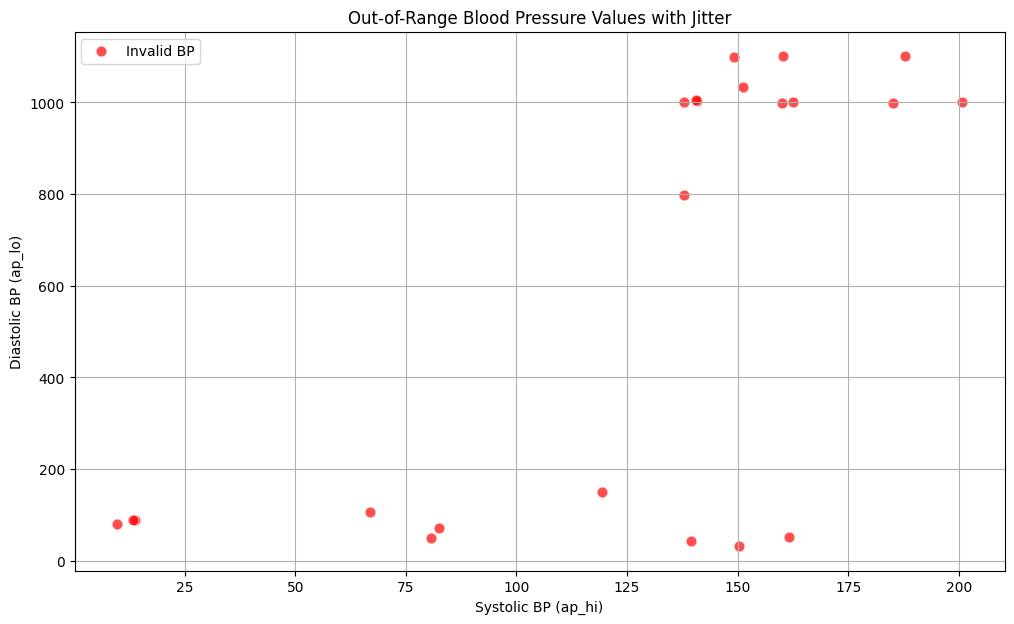

In [30]:
plt.figure(figsize=(12,7))

# Use seaborn scatterplot with jitter and transparency
sns.scatterplot(
    x=all_invalid_rows['ap_hi'] + np.random.normal(0, 2, len(all_invalid_rows)),
    y=all_invalid_rows['ap_lo'] + np.random.normal(0, 2, len(all_invalid_rows)),
    color='red',
    s=60,
    alpha=0.7,
    label='Invalid BP'
)

plt.xlabel("Systolic BP (ap_hi)")
plt.ylabel("Diastolic BP (ap_lo)")
plt.title("Out-of-Range Blood Pressure Values with Jitter")
plt.grid(True)
plt.legend()
plt.show()


In [31]:
# Verify data points 
print("Total unique points dropped:", len(all_invalid_rows))

Total unique points dropped: 22


# Why Is It Important To Remove Outliers From Blood Pressure Data?

**Impact on analysis:** Keeping these values can distort statistical calculations. Mean and standard deviation may be skewed, giving misleading central tendencies.

**KDE curve** Shows the overall shape of the distribution (bell curve). Extreme outliers would appear as long tails or separate peaks, but after cleaning, the curve is smooth and centered around physiologically plausible ranges.  

**Example:**  If a BP value is recorded as `ap_hi = 1000` due to a data entry error, including it in the dataset would dramatically inflate the mean systolic BP and could lead to wrong risk predictions for cardiovascular events.

**Solution:** Removing these outliers ensures the dataset is **clean, realistic, and suitable for analysis**, producing meaningful insights.

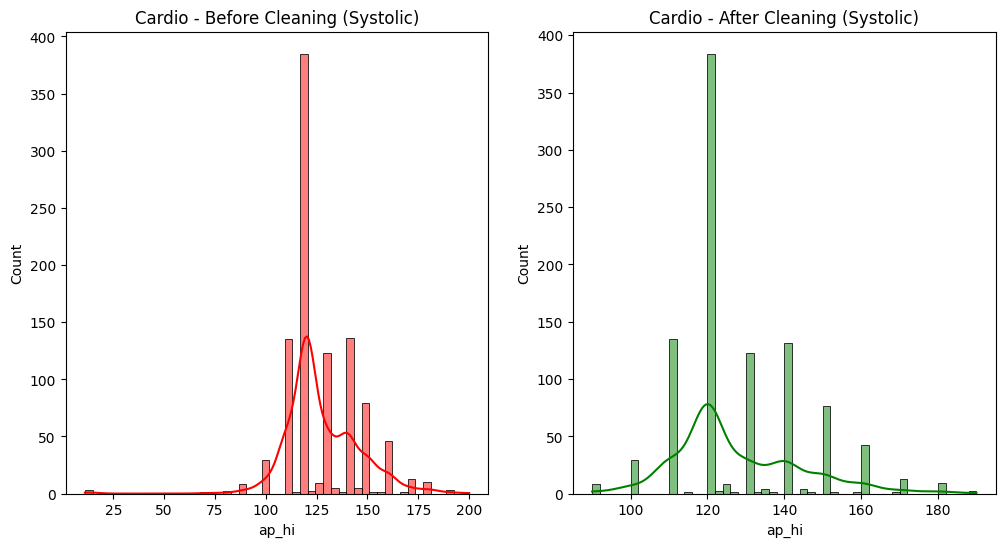

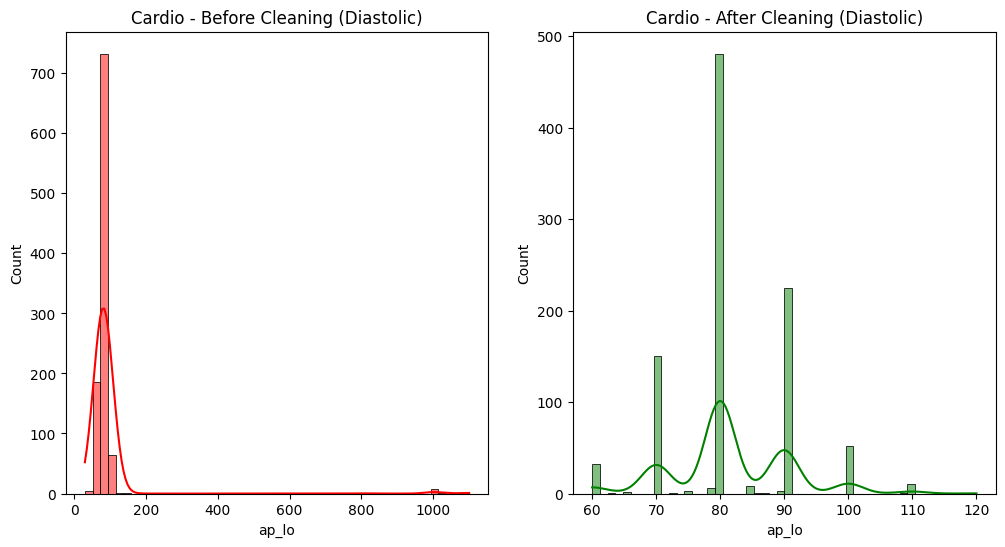

In [33]:
# Compare systolic distribution(Before)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(cardio_clean['ap_hi'], bins=50, kde=True, color='red')
plt.title('Cardio - Before Cleaning (Systolic)')

# Compare systolic distribution(After) 
plt.subplot(1,2,2)
sns.histplot(cardio_clean_drop['ap_hi'], bins=50, kde=True, color='green')
plt.title('Cardio - After Cleaning (Systolic)')
plt.show()

# Compare diastolic distribution(before)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(cardio_clean['ap_lo'], bins=50, kde=True, color='red')
plt.title('Cardio - Before Cleaning (Diastolic)')

# Compare diastolic distribution(After)
plt.subplot(1,2,2)
sns.histplot(cardio_clean_drop['ap_lo'], bins=50, kde=True, color='green')
plt.title('Cardio - After Cleaning (Diastolic)')
plt.show()

In [34]:
# Verified shape
cardio_clean_drop.shape

(978, 9)

# Why Choose Brain Stroke Dataset?

**Value:** Stroke is a leading cause of mortality and long-term disability worldwide. Understanding its risk factors, such as age, blood pressure, BMI, smoking status, and glucose levels, helps in early detection and prevention.

**Data Diversity:** The dataset contains a mix of demographic, behavioral, and medical measurements, making it suitable for practicing data cleaning, tidiness improvements, and exploratory analysis.

**Analysis Opportunities:**
- **Risk factor identification:** Allows exploring relationships between lifestyle/medical variables and stroke incidence.
- **Data quality exercises:** Presence of outliers, missing values, and categorical coding makes it ideal for demonstrating cleaning techniques.
  
**Practical Impact:** By working with this dataset, analysts gain hands on experience in preprocessing real world health data critical step in making actionable insights in public health and clinical research.

# Brain Stroke Dataset

## Data Audit: Quickly Identify Data Quality Issues

In [35]:
# Call data_audit function, view data
data_audit(stroke_raw)

Shape of DataFrame: (1000, 11)

Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data Types:
 gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values per Column:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Numeric Summary:
               age  hypertension  heart_disease  avg_glucose_level  \
count  1000.000000    1000.00000    1000.000000        1000.000000   
mean 

**Issues:** The dataset required multiple preprocessing steps, including converting age to integer years. Potential outliers were detected in `bmi` and `ave_glucose_level` due to unrealistic values. Data tidiness involved removing unnecessary columns and ensuring that data types and column names aligne across datasets, enabling consistency and facilitating future merging.

# Ensure Data Tidiness by Keeping Only Relevant Columns for Analysis

In [36]:
# Create a clean copy while dropping unnecessary columns
stroke_clean = stroke_raw.drop(columns=['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type'])

In [37]:
# Corrections 2
print('\nPotential outliers that need investagation:\n', stroke_clean[['avg_glucose_level', 'bmi']].describe())


Potential outliers that need investagation:
        avg_glucose_level          bmi
count        1000.000000  1000.000000
mean          106.093790    28.330500
std            45.002604     6.671513
min            55.340000    14.100000
25%            77.110000    23.700000
50%            92.205000    28.100000
75%           113.905000    32.300000
max           271.740000    48.900000


# Data Quality Issue: Age Conversion

**Dataset:** Stroke Sample Dataset

**Issue:** The age column is stored as a float (e.g., 67.0, 80.0). Since age is measured in full years, fractional values are not meaningful and may mislead analysis.

**Check Performed:** Created a backup of the original dataset (stroke_clean) to preserve raw data before modification.

**Results:** Converted the age column from float to integer (int64) in-place, replacing the original column to reflect full years.

**Justification:** Using integers ensures that age values accurately represent a descrete value. This prevents misinterpretation caused by decimal values, improves clarity in statistical analysis, visualization, and reporting, and aligns the dataset with standard practices in health research.

In [38]:
# Before type conversion 
print(stroke_clean[['age']].head())

        age
1129  65.00
3671  11.00
1041   1.56
2072  49.00
1375  49.00


In [39]:
# Convert age to integer in-place 
stroke_clean['age'] = stroke_clean['age'].astype(int)

# Preview the cleaned age column
print(stroke_clean[['age']].head())

      age
1129   65
3671   11
1041    1
2072   49
1375   49


In [40]:
# Before conversion 
print(stroke_clean['age'].dtypes)

int64


In [41]:
# Rename 'smoking_status' to 'smoke' drop 
stroke_clean = stroke_clean.rename(columns={"smoking_status": "smoke"})

In [42]:
# Keep only rows where 'smoke' is not 'Unknown'
stroke_clean = stroke_clean[stroke_clean["smoke"] != "Unknown"].copy()

# Define mapping
recode_map = {
    'never smoked': 0, 
    'smoked': 1, 
    'formerly smoked': 1
}

# Apply mapping (
stroke_clean['smoke'] = stroke_clean['smoke'].map(recode_map)

# Drop rows with NaN before converting to int
stroke_clean = stroke_clean.dropna(subset=['smoke']).copy()

# Convert to integer 
stroke_clean['smoke'] = stroke_clean['smoke'].astype(int)

# Reset index
stroke_clean = stroke_clean.reset_index(drop=True)

# Verify
print(stroke_clean['smoke'].dtypes)

int64


# Data Quality Issue: Outlier Removal
**Dataset:** Stroke Sample Dataset

**Issue:** Extreme values in age, avg_glucose_level, and bmi can distort statistics and analysis.

**Check Performed:** Applied the Interquartile Range (IQR) method to identify outliers. 
- Lower bound = Q1 – 1.5 × IQR 
- Upper bound = Q3 + 1.5 × IQR

**Results:** Rows with values outside the bounds were removed. The cleaned dataset contains only plausible, realistic values.

**Justification:** Removes extreme data points to ensure accurate statistical analysis and reliable modeling.

In [43]:
# Create a copy to clean using IQR method
stroke_clean_IQR = stroke_clean.copy()

numeric_cols = ['avg_glucose_level', 'bmi']
# Store all removed outliers for auditing purposes
removed_outliers = pd.DataFrame()

for col in numeric_cols:
    Q1 = stroke_clean_IQR[col].quantile(0.25)
    Q3 = stroke_clean_IQR[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Identify outliers for this column
    outliers = stroke_clean_IQR[(stroke_clean_IQR[col] < lower) | (stroke_clean_IQR[col] > upper)]
    
    # Append to outliers collection
    removed_outliers = pd.concat([removed_outliers, outliers])
    
    # Keep only non-outliers in the dataset
    stroke_clean_IQR = stroke_clean_IQR[(stroke_clean_IQR[col] >= lower) & (stroke_clean_IQR[col] <= upper)]
    
    print(f"{col}: {len(outliers)} outliers removed")

# Drop duplicates in case rows were flagged as outliers in multiple columns
removed_outliers = removed_outliers.drop_duplicates().reset_index(drop=True)

print(f"\nTotal unique outliers removed: {len(removed_outliers)}")

avg_glucose_level: 73 outliers removed
bmi: 8 outliers removed

Total unique outliers removed: 81


In [44]:
# Verified update
print(stroke_clean_IQR)

     gender  age  avg_glucose_level   bmi  smoke  stroke
0    Female   76              86.09  28.1      0       0
1    Female   17             105.91  30.8      0       0
2    Female   30              76.70  24.2      0       0
3    Female   29             101.28  22.7      0       0
4    Female   38             107.78  25.1      0       0
..      ...  ...                ...   ...    ...     ...
527  Female   41              89.14  37.4      1       0
528  Female   29              56.64  24.7      0       0
529    Male   63              78.43  18.8      0       0
530  Female   72             103.78  32.7      1       0
531  Female   26             168.15  22.9      0       0

[451 rows x 6 columns]


# Why Is It Important to Remove Outliers from Numeric Health Data?
**Impact on Analysis:** Extreme values in avg_glucose_level and bmi can distort statistical calculations. Mean, standard deviation, and correlations may be skewed, giving misleading trends or risk factor relationships.

# How Interpret The Visual

**Original plots (top row):** You’ll see whiskers, the box (IQR), and dots scattered far above/below (the outliers).

**Cleaned plots (bottom row):** Outliers are removed, so the distribution looks tighter and more compact.

**Key insight:** The code visually demonstrates how the dataset was altered by cleaning. If too many data points disappear, it may suggest the bounds were too strict (risk of over-cleaning).

Original dataset size (stroke): 532
Dataset size after removing outliers (stroke): 451


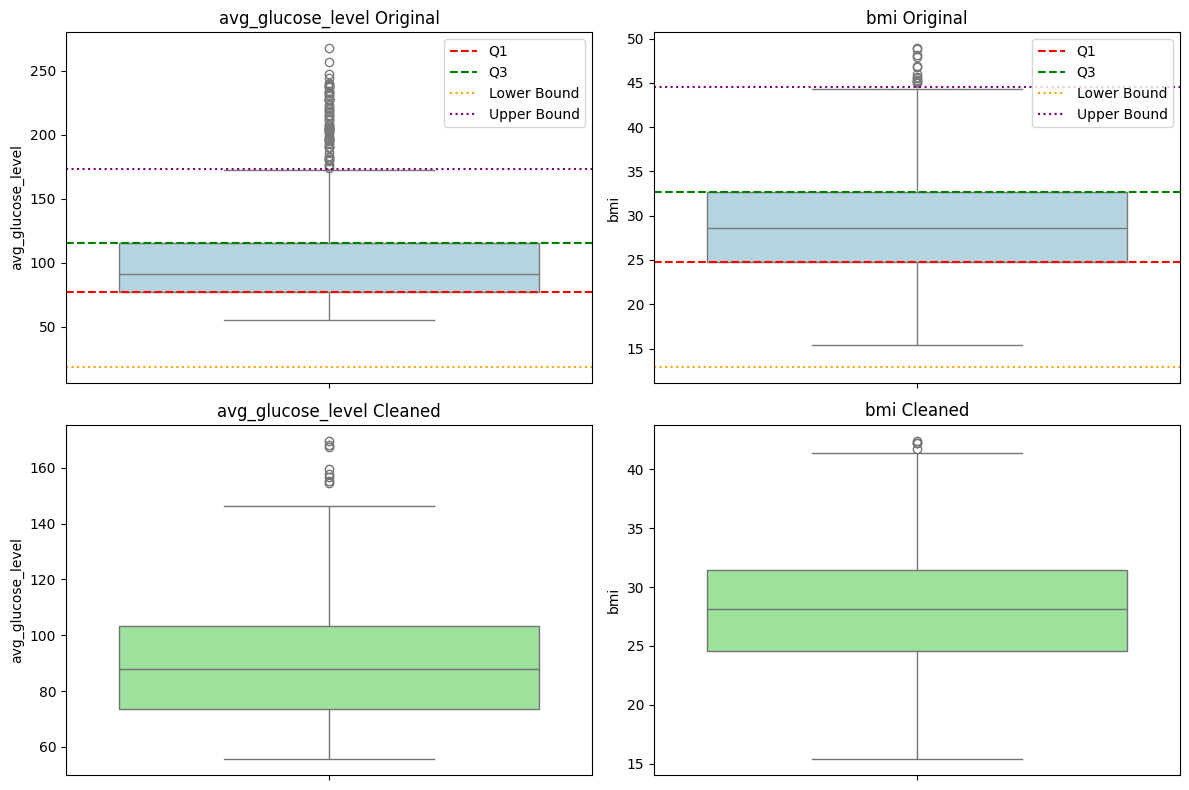

In [45]:
# Drop outlier rows
print(f'Original dataset size (stroke): {len(stroke_clean)}')
print(f'Dataset size after removing outliers (stroke): {len(stroke_clean_IQR)}')

# Boxplots before/after cleaning
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    # Original data
    plt.subplot(2, len(numeric_cols), i+1)
    sns.boxplot(y=stroke_clean[col], color='lightblue')
    plt.title(f'{col} Original')
    
    # Add IQR lines
    Q1, Q3 = stroke_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    for y, style, color, lbl in [(Q1, '--', 'red', 'Q1'),
                                 (Q3, '--', 'green', 'Q3'),
                                 (lower, ':', 'orange', 'Lower Bound'),
                                 (upper, ':', 'purple', 'Upper Bound')]:
        plt.axhline(y, color=color, linestyle=style, label=lbl)
    plt.legend()

    # Cleaned data
    plt.subplot(2, len(numeric_cols), i+1+len(numeric_cols))
    sns.boxplot(y=stroke_clean_IQR[col], color='lightgreen')
    plt.title(f'{col} Cleaned')

plt.tight_layout()
plt.show()

In [46]:
# Verified Before 
stroke_clean.shape

(532, 6)

In [47]:
# Verified After 
stroke_clean_IQR.shape

(451, 6)

# 4. Updated Data Store

# Raw and Cleaned 
- **Create folder:** Ensure `data_store/clean` exists to store cleaned data.  
- **Trim columns:** Keep only `age`, `gender`, `smoke`, and the outcome (`cardio` or `stroke`) for analysis.  
- **Save CSVs:** Export the trimmed datasets to the folder with descriptive names.  
- **Confirmation:** Print a message to confirm successful saving.

In [48]:
clean_folder = 'data_store/clean'
os.makedirs(clean_folder, exist_ok=True)
# Select only the required columns for trimmed datasets

# cardio_sample.to_csv(f'{clean_folder}/cardio_Raw.csv', index=False)
# stroke_sample.to_csv(f'{clean_folder}/stroke_Raw.csv', index=False)


cardio_trim = cardio_clean[['age', 'gender', 'smoke', 'cardio']]
stroke_trim = stroke_clean_IQR[['age', 'gender', 'smoke', 'stroke']]

# Save the trimmed datasets with informative names
cardio_trim.to_csv(f'{clean_folder}/cardio_clean_trimmed.csv', index=False)
stroke_trim.to_csv(f'{clean_folder}/stroke_clean_trimmed.csv', index=False)

print(f"Trimmed and full cleaned datasets saved in '{clean_folder}'.")

Trimmed and full cleaned datasets saved in 'data_store/clean'.


In [49]:
# Verified: correct data types for all columns
print(cardio_trim[['age','gender','smoke', 'cardio']].dtypes)

age        int64
gender    object
smoke      int64
cardio     int64
dtype: object


In [50]:
# Verified: correct data types for all columns
print(stroke_trim[['age','gender','smoke', 'stroke']].dtypes)

age        int64
gender    object
smoke      int64
stroke     int64
dtype: object


# Why Use the Brain Stroke and Cardiovascular Datasets Together?
**Value:**  
Stroke and cardiovascular disease are among the leading causes of death and disability worldwide. Both share common risk factors such as high blood pressure, high cholesterol, smoking, obesity, and diabetes. Studying them side by side strengthens understanding of overlapping and distinct risk patterns.

**Data Diversity:**
- **Cardiovascular Dataset:** Offers detailed physical and clinical measures (age, height, weight, systolic/diastolic blood pressure, cholesterol, glucose, lifestyle habits, and cardiovascular disease presence). Together, they give a comprehensive view of lifestyle, medical, and demographic contributors to cardiovascular health outcomes.
- **Brain Stroke Dataset:** Provides demographic (age, gender), lifestyle (smoking status, work type), and clinical indicators (hypertension, heart disease, glucose, BMI, stroke occurrence).

**Exploration Opportunities:**
- **Risk Factor Identification:** Explore how lifestyle factors (smoking, alcohol, physical activity) and medical measures (BP, cholesterol, glucose, BMI) jointly influence cardiovascular disease and stroke.
- **Gender-Specific Insights:** By analyzing heart disease prevalence by **smoking and alcohol habits separately for females and males**, we can identify which subgroups are at higher risk. For example:
    - **Females:** Most heart disease cases occur in non-smoking, non-drinking individuals, but small percentages exist in smokers or drinkers.
    - **Males:** Heart disease is more prevalent among smokers, particularly those who also consume alcohol.
- **Data Cleaning Practice:** Both datasets contain outliers, categorical codes, and missing values, making them ideal for demonstrating preprocessing, recoding, and tidying techniques.
- **Comparative Analysis:** By merging on shared attributes (age, gender, lifestyle habits), we can study whether individuals with cardiovascular risk factors are also more likely to show stroke indicators.

**Further Exploration:**  
This combined analysis allows researchers to:
- Identify high-risk subgroups across populations.  
- Understand how cardiovascular conditions and lifestyle factors differently impact **females vs. males**.  
- Apply machine learning or statistical modeling to predict risk and design better prevention strategies.

In [51]:
# Reset the index of cardio_trim to ensure row alignment
cardio_trim = cardio_trim.reset_index(drop=True)

# Reset the index of stroke_trim to ensure row alignment
stroke_trim = stroke_trim.reset_index(drop=True)

# Keep only the 'stroke' column from stroke_trim to avoid duplicate columns
stroke_only = stroke_trim[['stroke']]

# Concatenate cardio_trim and stroke_only horizontally (side by side)
combined_df = pd.concat([cardio_trim, stroke_only], axis=1)

In [52]:
# Define age bins and labels
bins = [0, 30, 40, 50, 60, 70, 120]
labels = ['<30','30-39','40-49','50-59','60-69','70+']

# Add age_group column
combined_df['age_group'] = pd.cut(combined_df['age'], bins=bins, labels=labels, right=False)
combined_df

,age,gender,smoke,cardio,stroke,age_group
0,43,Female,0,0,0.0,40-49
1,46,Female,1,1,0.0,40-49
2,52,Female,0,1,0.0,50-59
3,49,Female,0,0,0.0,40-49
4,55,Female,1,0,0.0,50-59
...,...,...,...,...,...,...
995,39,Male,0,1,NaN,30-39
996,44,Male,1,0,NaN,40-49
997,49,Female,0,0,NaN,40-49
998,45,Female,0,0,NaN,40-49


In [53]:
# Create a new column 'either_event' that flags if a patient has either a cardiovascular disease or a stroke.
# The expression checks if 'cardio' == 1 OR 'stroke' == 1 for each row. The result is converted to integer (1 for True, 0 for False).
combined_df['either_event'] = ((combined_df['cardio'] == 1) | (combined_df['stroke'] == 1)).astype(int)

# Group the combined dataframe by 'gender' and 'age_group' to summarize patient counts and disease cases
age_summary = combined_df.groupby(['gender','age_group'], observed=True).agg(
    # Count the total number of patients in each gender-age group
    total_patients=('age','count'),
    # Sum the number of cardiovascular cases in each group
    cardio_cases=('cardio','sum'),
    # Sum the number of stroke cases in each group
    stroke_cases=('stroke','sum')
).reset_index()  # Reset index so 'gender' and 'age_group' become regular columns again

In [54]:
# Display the summarized dataframe
age_summary

,gender,age_group,total_patients,cardio_cases,stroke_cases
0,Female,30-39,18,6,0.0
1,Female,40-49,180,62,4.0
2,Female,50-59,328,189,8.0
3,Female,60-69,115,80,5.0
4,Male,30-39,13,2,0.0
5,Male,40-49,110,43,1.0
6,Male,50-59,168,83,4.0
7,Male,60-69,68,42,1.0


In [55]:
age_summary.to_csv(f'{clean_folder}/merged_data.csv', index=False)

In [56]:
# Define age bins
bins = [0, 30, 40, 50, 60, 70, 120]
labels = ['<30','30-39','40-49','50-59','60-69','70+']

# Female subset
female_df = combined_df[combined_df['gender'] == 'Female'].copy()
female_df['age_group'] = pd.cut(female_df['age'], bins=bins, labels=labels, right=False)

# Male subset
male_df = combined_df[combined_df['gender'] == 'Male'].copy()
male_df['age_group'] = pd.cut(male_df['age'], bins=bins, labels=labels, right=False)


In [57]:
# Female summary
female_summary = female_df.groupby('age_group', observed=True).agg(
    total_patients=('age','count'),
    cardio_cases=('cardio','sum'),
    stroke_cases=('stroke','sum'),
    
).reset_index()

# Male summary
male_summary = male_df.groupby('age_group', observed=True).agg(
    total_patients=('age','count'),
    cardio_cases=('cardio','sum'),
    stroke_cases=('stroke','sum')
).reset_index()

In [58]:
# Calculate the cardiovascular disease rate for each row in female_summary
# cardio_cases / total_patients gives the proportion of patients with cardiovascular disease
female_summary['cardio_rate'] = (female_summary['cardio_cases']/female_summary['total_patients']*100).round(1)
# Calculate the stroke rate for each row in female_summary
# stroke_cases / total_patients gives the proportion of patients with stroke
female_summary['stroke_rate'] = (female_summary['stroke_cases']/female_summary['total_patients']*100).round(1)

In [59]:
# Verified
print("Female summary:")
female_summary

Female summary:


,age_group,total_patients,cardio_cases,stroke_cases,cardio_rate,stroke_rate
0,30-39,18,6,0.0,33.3,0.0
1,40-49,180,62,4.0,34.4,2.2
2,50-59,328,189,8.0,57.6,2.4
3,60-69,115,80,5.0,69.6,4.3


In [60]:
# Calculate the cardiovascular disease rate for each row in male_summary
# cardio_cases / total_patients gives the proportion of patients with cardiovascular disease
male_summary['cardio_rate'] = (male_summary['cardio_cases']/male_summary['total_patients']*100).round(1)
# Calculate the stroke rate for each row in male_summary
# stroke_cases / total_patients gives the proportion of patients with stroke
male_summary['stroke_rate'] = (male_summary['stroke_cases']/male_summary['total_patients']*100).round(1)

In [61]:
# Verified
print("Male summary:")
male_summary

Male summary:


,age_group,total_patients,cardio_cases,stroke_cases,cardio_rate,stroke_rate
0,30-39,13,2,0.0,15.4,0.0
1,40-49,110,43,1.0,39.1,0.9
2,50-59,168,83,4.0,49.4,2.4
3,60-69,68,42,1.0,61.8,1.5


# Cardio vs Stroke Occurrence Rates by Age Group (Female)
- **Purpose:** Compare cardiovascular disease and stroke rates across female age groups.  
- **Plot Type:** Grouped bar chart.  
- **X-axis:** Age groups.  
- **Y-axis:** Occurrence rate (%) of each condition.  
- **Bars:** 
  - Cardio rates in **sky blue**.  
  - Stroke rates in **salmon**.  
- **Features:** Includes axis labels, title, and legend for clarity.  
- **Visualization Goal:** Easily compare the prevalence of cardio vs stroke across different female age groups.

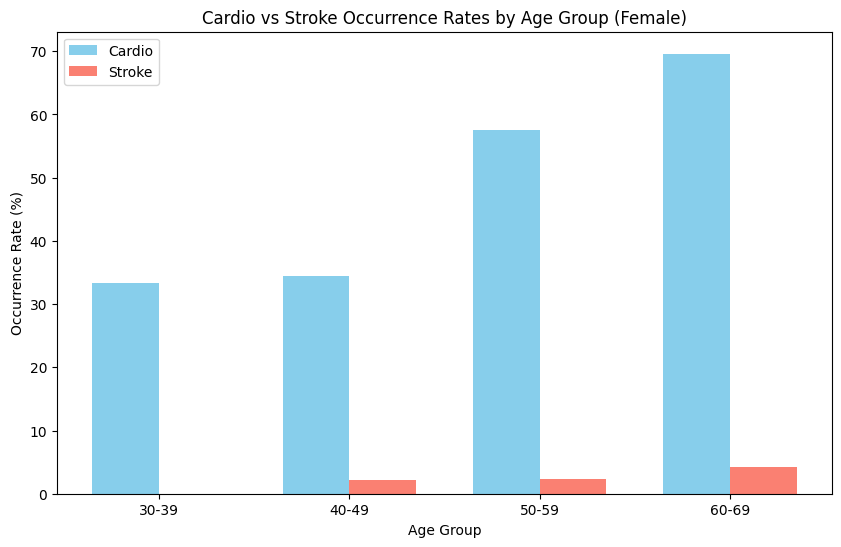

In [62]:
# Set figure size
plt.figure(figsize=(10,6))

# X-axis positions
x = range(len(female_summary['age_group']))

# Bar width
width = 0.35

# Plot bars
plt.bar([i - width/2 for i in x], female_summary['cardio_rate'], width=width, label='Cardio', color='skyblue')
plt.bar([i + width/2 for i in x], female_summary['stroke_rate'], width=width, label='Stroke', color='salmon')

# Labels and title
plt.xticks(ticks=x, labels=female_summary['age_group'])
plt.xlabel('Age Group')
plt.ylabel('Occurrence Rate (%)')
plt.title('Cardio vs Stroke Occurrence Rates by Age Group (Female)')
plt.legend()

plt.show()


In [63]:
print("Male summary:")
male_summary

Male summary:


,age_group,total_patients,cardio_cases,stroke_cases,cardio_rate,stroke_rate
0,30-39,13,2,0.0,15.4,0.0
1,40-49,110,43,1.0,39.1,0.9
2,50-59,168,83,4.0,49.4,2.4
3,60-69,68,42,1.0,61.8,1.5


# Cardio vs Stroke Occurrence Rates by Age Group (Male)
- **Purpose:** Compare cardiovascular disease and stroke rates across male age groups.  
- **Plot Type:** Grouped bar chart.  
- **X-axis:** Age groups.  
- **Y-axis:** Occurrence rate (%) of each condition.  
- **Bars:** 
  - Cardio rates in **sky blue**.  
  - Stroke rates in **salmon**.  
- **Features:** Includes axis labels, title, and legend for clarity.  
- **Visualization Goal:** Easily compare the prevalence of cardio vs stroke across different male age groups.

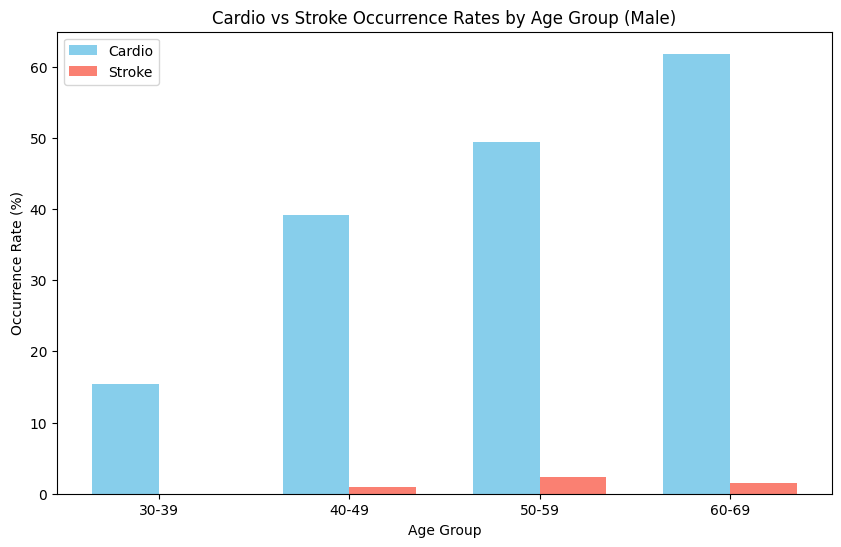

In [64]:
# Set figure size
plt.figure(figsize=(10,6))

# X-axis positions
x = range(len(male_summary['age_group']))

# Bar width
width = 0.35

# Plot bars
plt.bar([i - width/2 for i in x], male_summary['cardio_rate'], width=width, label='Cardio', color='skyblue')
plt.bar([i + width/2 for i in x], male_summary['stroke_rate'], width=width, label='Stroke', color='salmon')

# Labels and title
plt.xticks(ticks=x, labels=male_summary['age_group'])
plt.xlabel('Age Group')
plt.ylabel('Occurrence Rate (%)')
plt.title('Cardio vs Stroke Occurrence Rates by Age Group (Male)')
plt.legend()

plt.show()

# 5. Answer the research question

# Cardiovascular and Stroke Occurrence by Age Group and Gender
The analysis shows that **cardiovascular disease rates increase steadily with age for both males and females**, peaking in the 60–69 age group, while **stroke rates remain consistently low across all age groups**. Age appears to be a stronger predictor of cardiovascular risk than gender. Missing data in the youngest (<30) and oldest (70+) groups reflects small sample sizes and should be considered when interpreting the results.

# Uncovering Key Patterns in Patient Data.
If I had more time to complete the project, I would:**Integrate additional datasets to capture more patient information and lifestyle factors**, such as diet, exercise, and alcohol consumption. I would also **investigate remaining data quality issues**, including outliers, missing values, and variable inconsistencies, to improve the reliability of the analysis. This would allow for a **deeper exploration of risk factors** and their interactions with demographics, helping to better understand patterns in cardiovascular and stroke occurrence. Additionally, I would **explore more advanced research questions**, such as predicting disease risk based on combined clinical and lifestyle variables.


/Users/kristablevins/jupyter-env
